
--- Classification Report ---
              precision    recall  f1-score   support

           0       0.96      0.99      0.98      1701
           1       0.94      0.81      0.87       325

    accuracy                           0.96      2026
   macro avg       0.95      0.90      0.92      2026
weighted avg       0.96      0.96      0.96      2026



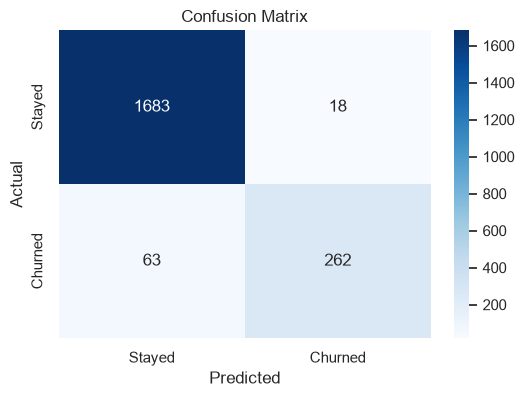

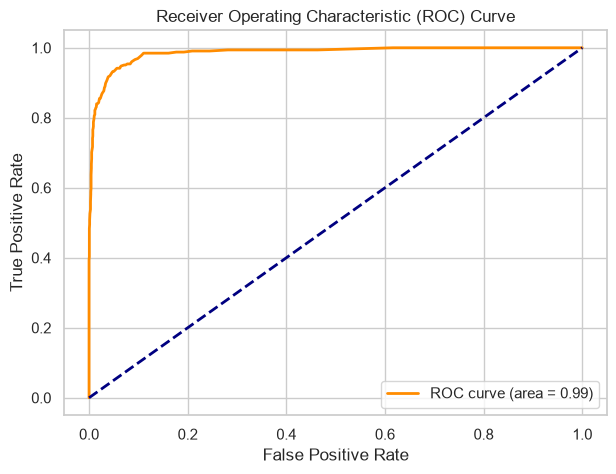

In [ ]:
# ==============================================================================
# DEVELOPERSHUB CORPORATION - ADVANCED INTERNSHIP TASKS
# TASK 1: Customer Churn Classification & Explainable AI (XAI)
# ==============================================================================

# 1. Import Libraries
import warnings
warnings.filterwarnings('ignore') # Suppresses deprecation and runtime warnings for a clean submission

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, f1_score
import xgboost as xgb
import shap

# Set styling
sns.set_theme(style="whitegrid")

# ------------------------------------------------------------------------------
# 2. Load and Clean Dataset
# ------------------------------------------------------------------------------
df_bank = pd.read_csv('BankChurners.csv')

# Drop the client identifier and the two trailing alternative Naive Bayes columns mentioned in the data spec
cols_to_drop = [
    'CLIENTNUM',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
    'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'
]
df_bank = df_bank.drop(columns=cols_to_drop)

# Encode Target Variable (Attrited Customer = 1, Existing Customer = 0)
df_bank['Attrition_Flag'] = df_bank['Attrition_Flag'].map({'Existing Customer': 0, 'Attrited Customer': 1})

# ------------------------------------------------------------------------------
# 3. Categorical Encoding
# ------------------------------------------------------------------------------
# Updated line for compatibility across Pandas 2.x and 3.x versions
categorical_cols = df_bank.select_dtypes(include=['object', 'string']).columns.tolist()

# Apply label encoding to categorical strings
le = LabelEncoder()
for col in categorical_cols:
    df_bank[col] = le.fit_transform(df_bank[col])

# Splitting Features and Target
X = df_bank.drop('Attrition_Flag', axis=1)
y = df_bank['Attrition_Flag']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ------------------------------------------------------------------------------
# 4. Model Training & Evaluation
# ------------------------------------------------------------------------------
# Using Random Forest as requested in guidelines
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Print metrics
print("\n--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Evaluation
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Stayed', 'Churned'], yticklabels=['Stayed', 'Churned'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

# ROC Curve Evaluation
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (area = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()

# ------------------------------------------------------------------------------
# 5. Explainable AI (XAI) using SHAP
# ------------------------------------------------------------------------------
print("\n--- Calculating SHAP Values for Model Interpretation ---")
# Use TreeExplainer for Tree-based models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

# Summary Plot showing overall feature importance impact
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values[1], X_test, plot_type="bar")
plt.show()

# Detailed Summary Plot
shap.summary_plot(shap_values[1], X_test)
plt.show()